In [1]:
"""
Limitations:
I can only find a complete dataset for this season, and as such the model is only trained on 20 gameweeks worth of data. 
The model can't predict individual player match ups
The dataset doesn't contain some data which could be important:
Yellow cards, Red cards, Own goals, Is penatly taker, bonus points
---
Improvements:
Integrate a data pipeline to get last gameweeks player data
Adjust points to be scaled positionally, ie goals by defenders are weighted more highly
Integrate possession value models such as xT
"""

"\nLimitations:\nI can only find a complete dataset for this season, and as such the model is only trained on 20 gameweeks worth of data. \nThe model can't predict individual player match ups\nThe dataset doesn't contain some data which could be important:\nYellow cards, Red cards, Own goals, Is penatly taker, bonus points\n---\nImprovements:\nIntegrate a data pipeline to get last gameweeks player data\nAdjust points to be scaled positionally, ie goals by defenders are weighted more highly\nIntegrate possession value models such as xT\n"

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fpl-2526-threshold-5/fpl-data-stats-24-25.csv


In [3]:
#libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier


In [4]:
#read data
df = pd.read_csv('/kaggle/input/fpl-2526-threshold-5/fpl-data-stats-24-25.csv')

In [5]:
#sanity check
df.loc()

In [6]:
#most of my feature engineering has been done in excel, but in an effort to improve accuracy, \
#there are some more features I want to create

df = df.sort_values(['web_name', 'gameweek'])

df['clean_sheet_5gra'] = df.groupby('web_name')['clean_sheet'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean().shift(1)
)

In [7]:
#I needed the gameday data in my spreadsheet to create the rolling averages, \
#however including this in training will ruin the model \
#It isn't going to know who scored a goal that week before its happened
#Hence I will drop all gameday data, along with any other irrelevant data
df = df.drop(['minutes', 'expected_goals', 'goals', 'expected_assists', \
              'assists', 'expected_goals_conceded', 'expected_clean_sheet',\
              'clean_sheet', 'defensive_contribution'], axis=1)
#I also want to drop the players that aren't getting any minutes at all to avoid class imbalance
df = df[df['Mins_3gra'] >= 30]

In [8]:
#convert objects to floats where needed. any #NAN in excel become na here
df['def_con_5gra'] = pd.to_numeric(df['def_con_5gra'], errors='coerce')
df['xG_conceded_5gra'] = pd.to_numeric(df['xG_conceded_5gra'], errors='coerce')
df['opp_xG_conceded_5gra'] = pd.to_numeric(df['opp_xG_conceded_5gra'], errors='coerce')
df['clean_sheet_5gra'] = pd.to_numeric(df['clean_sheet_5gra'], errors='coerce')

In [9]:
#check for null
df.isna().sum()

id                        0
element_type              0
web_name                  0
team_name                 0
opponent_team_name        0
was_home                  0
gameweek                  0
Mins_3gra                 0
xG_5gra                   0
xA_5gra                   0
def_con_5gra              0
total_points              0
high_points               0
xG_conceded_5gra        228
opp_xG_conceded_5gra    228
clean_sheet_5gra        236
dtype: int64

In [10]:
#fill na's with median for that column
columns_to_fill = ['def_con_5gra', 'xG_conceded_5gra', 'opp_xG_conceded_5gra', 'clean_sheet_5gra']

for col in columns_to_fill:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [11]:
#sanity check
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6030 entries, 1 to 16559
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6030 non-null   int64  
 1   element_type          6030 non-null   int64  
 2   web_name              6030 non-null   object 
 3   team_name             6030 non-null   object 
 4   opponent_team_name    6030 non-null   object 
 5   was_home              6030 non-null   bool   
 6   gameweek              6030 non-null   int64  
 7   Mins_3gra             6030 non-null   float64
 8   xG_5gra               6030 non-null   float64
 9   xA_5gra               6030 non-null   float64
 10  def_con_5gra          6030 non-null   float64
 11  total_points          6030 non-null   int64  
 12  high_points           6030 non-null   int64  
 13  xG_conceded_5gra      6030 non-null   float64
 14  opp_xG_conceded_5gra  6030 non-null   float64
 15  clean_sheet_5gra      603

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'element_type'}>,
        <Axes: title={'center': 'gameweek'}>],
       [<Axes: title={'center': 'Mins_3gra'}>,
        <Axes: title={'center': 'xG_5gra'}>,
        <Axes: title={'center': 'xA_5gra'}>],
       [<Axes: title={'center': 'def_con_5gra'}>,
        <Axes: title={'center': 'total_points'}>,
        <Axes: title={'center': 'high_points'}>],
       [<Axes: title={'center': 'xG_conceded_5gra'}>,
        <Axes: title={'center': 'opp_xG_conceded_5gra'}>,
        <Axes: title={'center': 'clean_sheet_5gra'}>]], dtype=object)

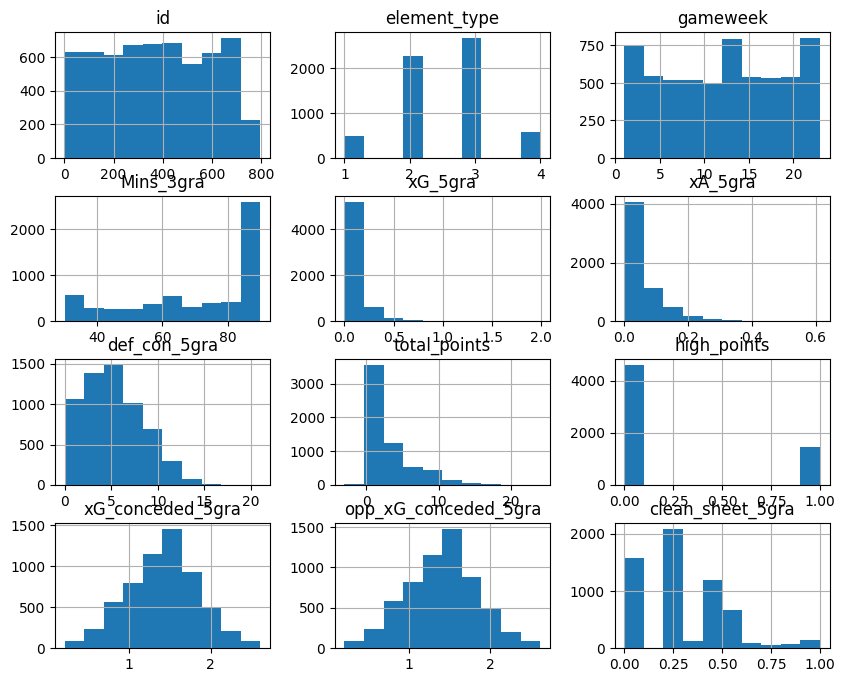

In [12]:
#histograms
df.hist(figsize=(10,8))

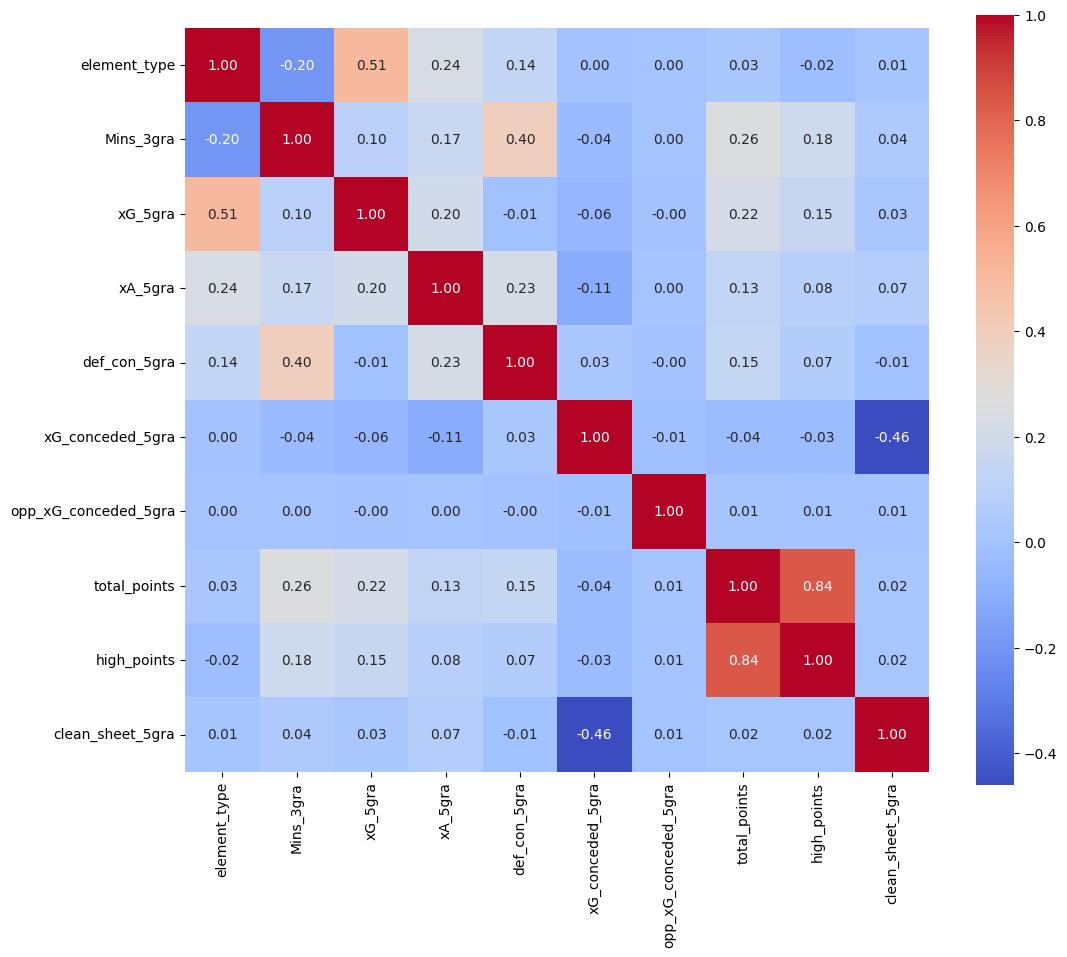

In [13]:
#heatmap
correlation = df[['element_type', 'Mins_3gra', 'xG_5gra', 'xA_5gra', 'def_con_5gra',\
                  'xG_conceded_5gra', 'opp_xG_conceded_5gra', 'total_points', 'high_points', \
                 'clean_sheet_5gra']].corr()
plt.figure(figsize=(12,10))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.show()

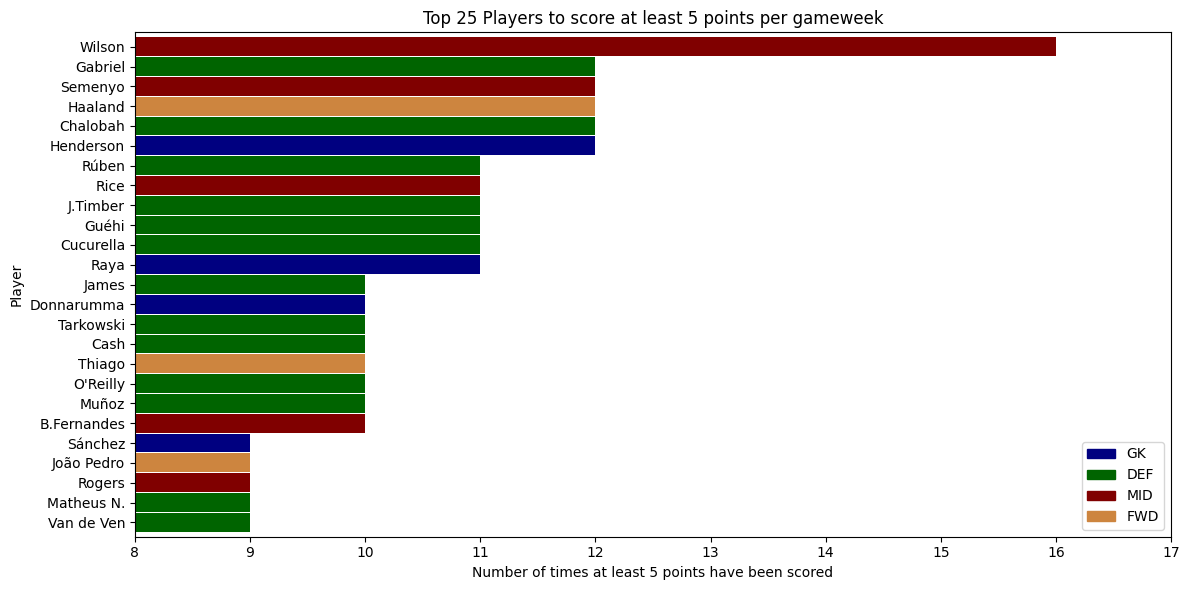

In [14]:
#which players achieve over 5 points most often, and which positions are they? \
#This can help me decide a formation
top_players = df.groupby('web_name').agg({
    'high_points': 'sum',
    'element_type': 'first'
}).sort_values('high_points', ascending=True).tail(25)

colors_map = {
    1: 'navy',
    2: 'darkgreen',
    3: 'maroon',
    4: 'peru'
}

colors = top_players['element_type'].map(colors_map)

plt.figure(figsize=(12, 6))
top_players['high_points'].plot(kind='barh', color=colors, width=0.95)
plt.xlim(8, 17)
plt.xlabel('Number of times at least 5 points have been scored')
plt.ylabel('Player')
plt.title('Top 25 Players to score at least 5 points per gameweek')

gk_patch = mpatches.Patch(color='navy', label='GK')
def_patch = mpatches.Patch(color='darkgreen', label='DEF')
mid_patch = mpatches.Patch(color='maroon', label='MID')
fwd_patch = mpatches.Patch(color='peru', label='FWD')

plt.legend(handles=[gk_patch, def_patch, mid_patch, fwd_patch], loc='lower right')
plt.tight_layout()
plt.show()

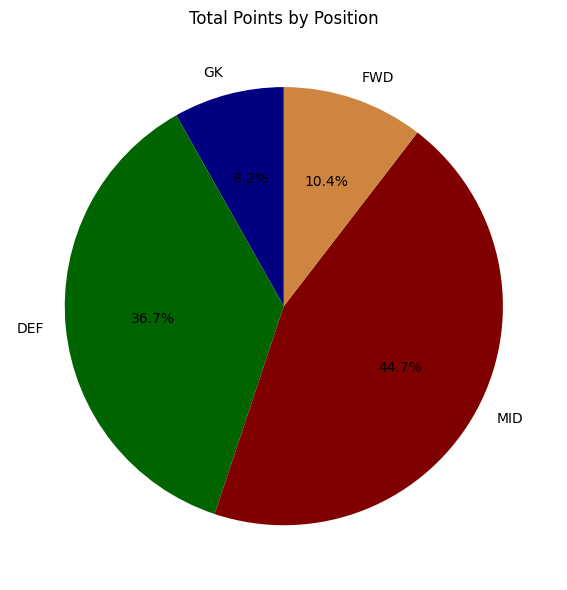

In [15]:
#nterestingly, over 50% of these players are defenders. Lets see what portion of the total points\
#have been scored by each position
position_points = df.groupby('element_type')['total_points'].sum()

labels = ['GK', 'DEF', 'MID', 'FWD']
colors = ['navy', 'darkgreen', 'maroon', 'peru']

plt.figure(figsize=(6,6))
plt.pie(position_points, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Total Points by Position')
plt.tight_layout()
plt.show()


In [16]:
#the last graph is interesting but a little misleading, as if we check the counts then we can see \
# there's an imbalance in the number of players in each position
df_filtered = df[df['Mins_3gra'] >= 60]

player_count = df_filtered.groupby('element_type')['web_name'].nunique()

position_names = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

for position, count in player_count.items():
    print(f"{position_names[position]}: {count} players")

#so actually it mostly lines up with the player count for each position

GK: 29 players
DEF: 139 players
MID: 161 players
FWD: 39 players


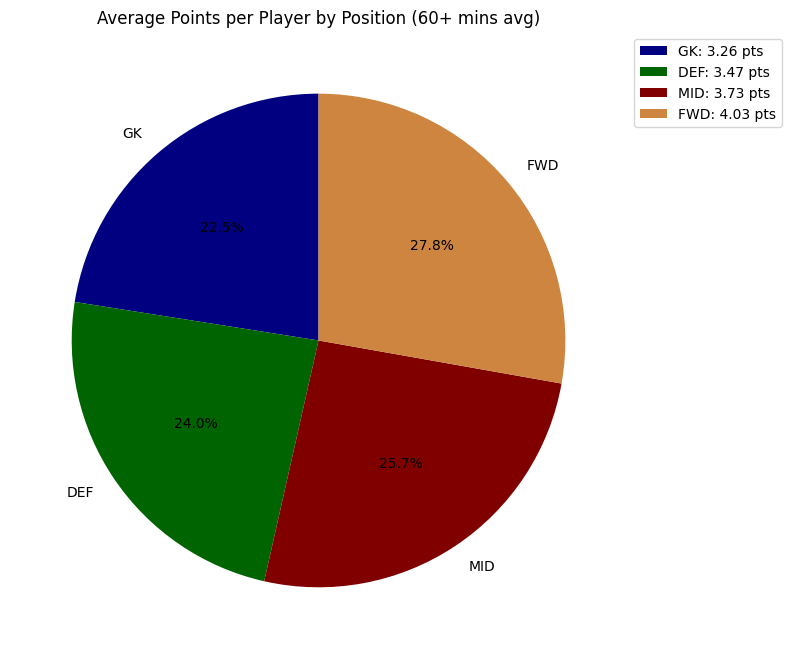

In [17]:
#lets check the average points gained by each position per game, for players that are \
#playing over 60 mins each week
df_filtered = df[df['Mins_3gra'] >= 60]

position_avg_points = df_filtered.groupby('element_type')['total_points'].mean()

labels = ['GK', 'DEF', 'MID', 'FWD']
colors = ['navy', 'darkgreen', 'maroon', 'peru']

plt.figure(figsize=(8, 8))
plt.pie(position_avg_points, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Average Points per Player by Position (60+ mins avg)')
plt.legend([f'{labels[i]}: {position_avg_points.iloc[i]:.2f} pts' for i in range(len(labels))], 
           loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [18]:
#so although defenders make up the majority of the players to score over 5 points in a gameweek,\
#it's still attackers that are scoring the highest points per gameweek. \
#This tells us a lot about the consistency of each position.

In [19]:
#split data into train/validate/test. I have data for up to gw 23, so i will use 1-19 for train,\
#20-23 for test
train = df[df['gameweek'] <= 19]
test = df[df['gameweek'].isin([20, 21, 22, 23])]

In [20]:
#split into target and features
X_train = train.drop(['high_points', 'total_points', 'id', 'gameweek'], axis=1) 
y_train = train['high_points']

X_test = test.drop(['high_points', 'total_points', 'id', 'gameweek'], axis=1)
y_test = test['high_points']

In [21]:
#divide into numerical and categorical features for preprocessing
num_feats = ['element_type', 'Mins_3gra', 'xG_5gra', 'xA_5gra',\
             'def_con_5gra', 'xG_conceded_5gra', 'opp_xG_conceded_5gra']
cat_feats = ['web_name', 'team_name', 'opponent_team_name', 'was_home']

In [22]:
#create individual pipelines
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [23]:
#combine these pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_feats),
    ('cat', cat_pipeline, cat_feats)
])

In [24]:
#transform the data so it is ingestible
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

In [25]:
#fit each of the models

random_forest = RandomForestClassifier(class_weight='balanced')
random_forest.fit(X_train_ready, y_train)

xgb_model = XGBClassifier(random_state=42, scale_pos_weight=3)
xgb_model.fit(X_train_ready, y_train)

svm_model = SVC(random_state=42, class_weight='balanced', probability=True)
svm_model.fit(X_train_ready, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [26]:
#create an ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', random_forest),
        ('xgb', xgb_model),
        ('svm', svm_model)
    ],
    voting='soft',
    weights=[2, 2, 1]
)

ensemble.fit(X_train_ready, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced')),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            gr...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('svm',
                              SVC(class_weight='balanced', probability=True,
                                  random_state=42))],
                 voting='soft', weights=[2, 2, 1])

In [27]:
#predict using each model and the ensemble, and show the accuracy and confusion matrix for each
predictions = {}

for model in (random_forest, xgb_model, svm_model, ensemble):
    model.fit(X_train_ready, y_train)
    y_pred_ens = model.predict(X_test_ready)
    model_name = model.__class__.__name__
    predictions[model_name] = y_pred_ens
    print(f"{model_name} accuracy = {accuracy_score(y_test, y_pred_ens):.2f}")

print("\n" + "="*50)
print("CONFUSION MATRICES")
print("="*50)

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    print(confusion_matrix(y_test, y_pred))

RandomForestClassifier accuracy = 0.76
XGBClassifier accuracy = 0.64
SVC accuracy = 0.59
VotingClassifier accuracy = 0.73

CONFUSION MATRICES

RandomForestClassifier:
[[781  31]
 [227  22]]

XGBClassifier:
[[582 230]
 [150  99]]

SVC:
[[508 304]
 [129 120]]

VotingClassifier:
[[713  99]
 [190  59]]


In [28]:
#prepare model for gw24 predictions
latest_gw = df['gameweek'].max()
latest_data = df[df['gameweek'] == latest_gw].copy()

print(f"Players with data from GW {latest_gw}: {len(latest_data)}")

next_gameweek = 25

fixtures_gw25 = {
    'Leeds': ("Nott'm Forest", True),
    "Nott'm Forest": ('Leeds', False),
    'Man Utd': ('Spurs', True),
    'Spurs': ('Man Utd', False),
    'Arsenal': ('Sunderland', True),
    'Sunderland': ('Arsenal', False),
    'Bournemouth': ('Aston Villa', True),
    'Aston Villa': ('Bournemouth', False),
    'Burnley': ('West Ham', True),
    'West Ham': ('Burnley', False),
    'Fulham': ('Everton', True),
    'Everton': ('Fulham', False),
    'Wolves': ('Chelsea', True),
    'Chelsea': ('Wolves', False),
    'Newcastle': ('Brentford', True),
    'Brentford': ('Newcastle', False),
    'Brighton': ('Crystal Palace', True),
    'Crystal Palace': ('Brighton', False),
    'Liverpool': ('Man City', True),
    'Man City': ('Liverpool', False)
}

def get_next_fixture(row):
    team = row['team_name']
    if team in fixtures_gw25:
        opponent, is_home = fixtures_gw25[team]
        return pd.Series({'opponent_team_name': opponent, 'was_home': is_home})
    return pd.Series({'opponent_team_name': None, 'was_home': None})

latest_data[['next_opponent', 'next_home']] = latest_data.apply(get_next_fixture, axis=1)

Players with data from GW 23: 260


In [29]:
opponent_stats = df.groupby('team_name').agg({
    'xG_conceded_5gra': 'last'
}).reset_index()
opponent_stats.columns = ['team_name', 'opp_xG_conceded_5gra']

latest_data = latest_data.merge(
    opponent_stats,
    left_on='next_opponent',
    right_on='team_name',
    how='left',
    suffixes=('', '_opp')
)

In [30]:
latest_data['gameweek'] = next_gameweek
latest_data['opponent_team_name'] = latest_data['next_opponent']
latest_data['was_home'] = latest_data['next_home']

features_to_keep = X_train.columns.tolist()
X_next_gw = latest_data[features_to_keep]

X_next_gw_ready = preprocessor.transform(X_next_gw)

In [31]:
predictions_proba = ensemble.predict_proba(X_next_gw_ready)[:, 1]
predictions_class = ensemble.predict(X_next_gw_ready)

latest_data['prob_5plus_points'] = predictions_proba
latest_data['predicted_5plus'] = predictions_class

results = latest_data[['web_name', 'team_name', 'element_type', 'next_opponent', 
                        'next_home', 'prob_5plus_points', 'predicted_5plus']].copy()

results = results.sort_values('prob_5plus_points', ascending=False)

print("\nTop 20 Predicted Players for GW25:")
print(results.head(20))


Top 20 Predicted Players for GW25:
          web_name    team_name  element_type  next_opponent  next_home  \
179           Raya      Arsenal             1     Sunderland       True   
77         Gabriel      Arsenal             2     Sunderland       True   
195         Saliba      Arsenal             2     Sunderland       True   
113       J.Timber      Arsenal             2     Sunderland       True   
32           Bowen     West Ham             4        Burnley      False   
223         Thiago    Brentford             4      Newcastle      False   
41   Calvert-Lewin        Leeds             4  Nott'm Forest       True   
183           Rice      Arsenal             3     Sunderland       True   
101           Hill  Bournemouth             2    Aston Villa       True   
46        Chalobah      Chelsea             2         Wolves      False   
219           Taty     West Ham             4        Burnley      False   
232       Truffert  Bournemouth             2    Aston Villa    